In [1]:
# ─── Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

In [2]:
# ─── Load Clustered RFM Data ───────────────────────────────
# This is the final enriched dataset with both rule-based segments
# and ML cluster labels — the result of all previous days' work

rfm = pd.read_csv('../data/processed/rfm_clustered.csv')
df  = pd.read_csv('../data/processed/clean_retail.csv',
                  parse_dates=['InvoiceDate'])

print(f"RFM shape: {rfm.shape}")
print(f"Clean data shape: {df.shape}")
print(f"\nSegments: {rfm['Segment'].nunique()}")
print(f"Clusters: {rfm['Cluster_Label'].nunique()}")
rfm.head()

RFM shape: (5878, 12)
Clean data shape: (779425, 9)

Segments: 9
Clusters: 4


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Segment,Cluster,Cluster_Label
0,12346,326,12,522.62,2,5,2,3.05,252,Need Attention,1,Loyal Customers
1,12347,2,8,4822.65,5,4,5,4.65,545,Champions,2,At Risk
2,12348,75,5,1793.95,3,4,4,3.70,344,Loyal Customers,1,Loyal Customers
3,12349,19,4,3612.54,5,3,5,4.30,535,Loyal Customers,3,Lost / Inactive
4,12350,310,1,309.35,2,1,2,1.65,212,Hibernating,0,VIP Customers


In [3]:
# ─── Executive Summary KPIs ────────────────────────────────
# The first thing any stakeholder wants to see is the big numbers
# These KPIs frame the entire analysis — everything else is detail
# Professional reports always lead with KPIs before diving into segments

total_customers  = rfm['Customer ID'].nunique()
total_revenue    = rfm['Monetary'].sum()
avg_order_value  = df['Revenue'].sum() / df['Invoice'].nunique()
avg_frequency    = rfm['Frequency'].mean()
avg_recency      = rfm['Recency'].mean()
champion_revenue = rfm[rfm['Segment']=='Champions']['Monetary'].sum()
champion_pct     = champion_revenue / total_revenue * 100

print("=" * 55)
print("       EXECUTIVE SUMMARY — RFM ANALYSIS")
print("=" * 55)
print(f"  Total Customers Analyzed  : {total_customers:>10,}")
print(f"  Total Revenue (GBP)       : £{total_revenue:>10,.0f}")
print(f"  Avg Order Value (GBP)     : £{avg_order_value:>10,.2f}")
print(f"  Avg Purchase Frequency    : {avg_frequency:>10.1f} orders")
print(f"  Avg Recency (days)        : {avg_recency:>10.0f} days")
print(f"  Champion Revenue Share    : {champion_pct:>9.1f}%")
print("=" * 55)

       EXECUTIVE SUMMARY — RFM ANALYSIS
  Total Customers Analyzed  :      5,878
  Total Revenue (GBP)       : £15,410,980
  Avg Order Value (GBP)     : £    416.86
  Avg Purchase Frequency    :        6.3 orders
  Avg Recency (days)        :        201 days
  Champion Revenue Share    :      68.9%


Top 25.0% of customers generate 80% of revenue


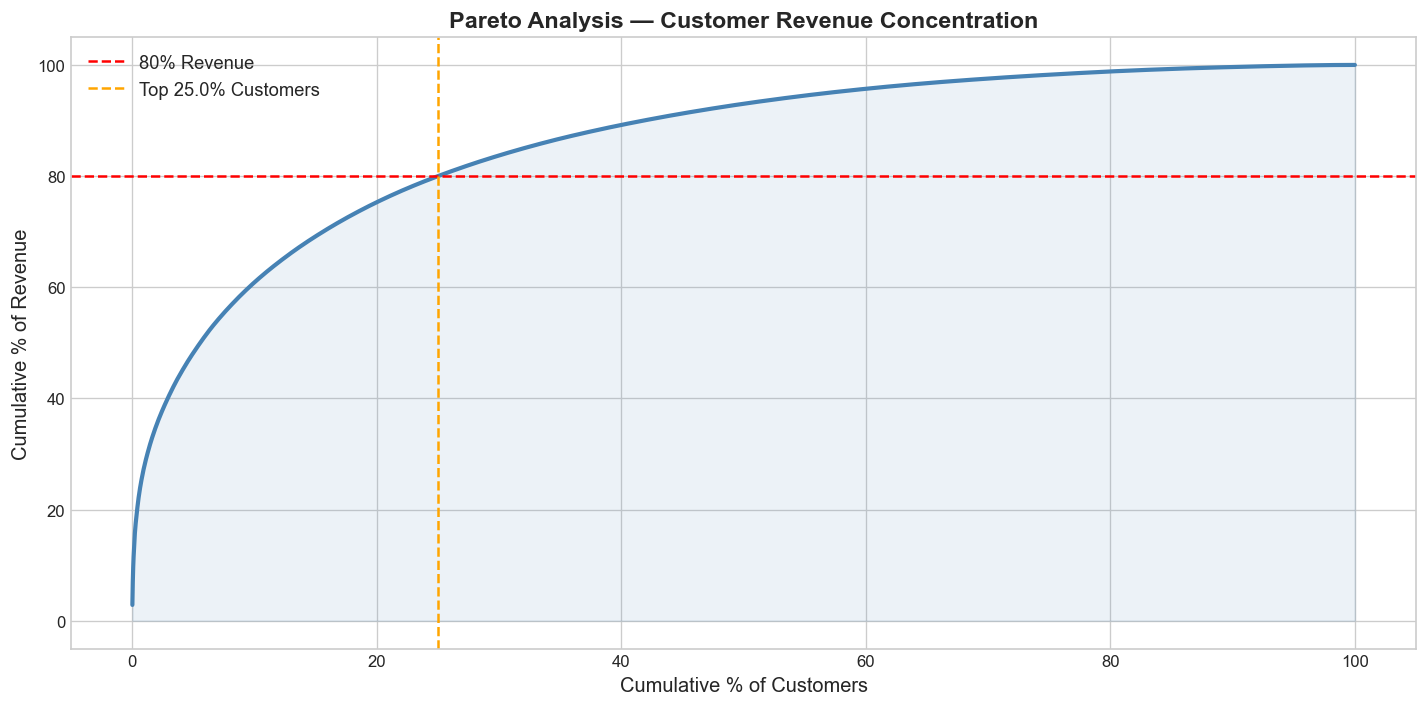

In [4]:
# ─── Pareto Analysis ───────────────────────────────────────
# The Pareto principle: ~20% of customers drive ~80% of revenue
# Proving or disproving this in your data is a powerful insight
# It tells the business where to focus retention efforts

rfm_sorted = rfm.sort_values('Monetary', ascending=False).reset_index(drop=True)
rfm_sorted['Cumulative_Revenue'] = rfm_sorted['Monetary'].cumsum()
rfm_sorted['Cumulative_Revenue_Pct'] = (rfm_sorted['Cumulative_Revenue'] / 
                                         rfm_sorted['Monetary'].sum() * 100)
rfm_sorted['Customer_Pct'] = (rfm_sorted.index + 1) / len(rfm_sorted) * 100

# Find where 80% revenue is reached
pct_customers_for_80 = rfm_sorted[
    rfm_sorted['Cumulative_Revenue_Pct'] >= 80
]['Customer_Pct'].iloc[0]

print(f"Top {pct_customers_for_80:.1f}% of customers generate 80% of revenue")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rfm_sorted['Customer_Pct'], 
        rfm_sorted['Cumulative_Revenue_Pct'],
        color='steelblue', linewidth=2.5)
ax.axhline(80, color='red', linestyle='--', linewidth=1.5, label='80% Revenue')
ax.axvline(pct_customers_for_80, color='orange', linestyle='--', 
           linewidth=1.5, label=f'Top {pct_customers_for_80:.1f}% Customers')
ax.fill_between(rfm_sorted['Customer_Pct'],
                rfm_sorted['Cumulative_Revenue_Pct'],
                alpha=0.1, color='steelblue')
ax.set_xlabel('Cumulative % of Customers', fontsize=12)
ax.set_ylabel('Cumulative % of Revenue', fontsize=12)
ax.set_title('Pareto Analysis — Customer Revenue Concentration', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../reports/pareto_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

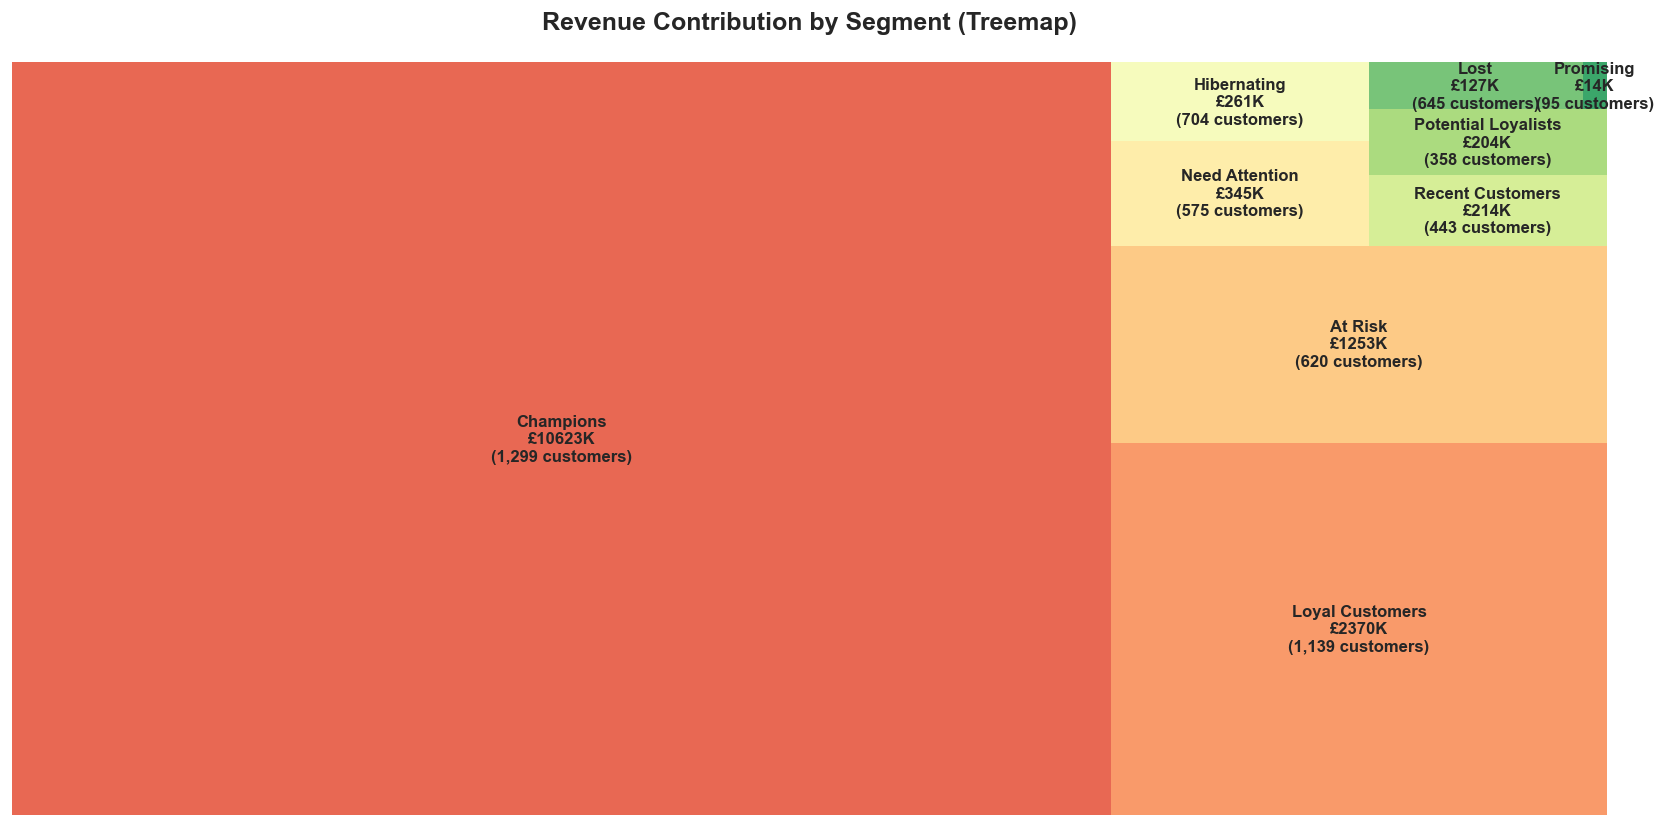

In [7]:
# ─── Segment Treemap ───────────────────────────────────────
# Treemap shows proportional revenue contribution per segment
# Size = revenue, making it instantly clear which segments matter most
# More visually compelling than a pie chart for portfolio

import squarify


seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
seg_counts  = rfm.groupby('Segment')['Customer ID'].count()

colors = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(seg_revenue)))

plt.figure(figsize=(14, 7))
squarify.plot(
    sizes=seg_revenue.values,
    label=[f"{s}\n£{v/1000:.0f}K\n({seg_counts[s]:,} customers)" 
           for s, v in seg_revenue.items()],
    color=colors,
    alpha=0.85,
    text_kwargs={'fontsize': 10, 'fontweight': 'bold'}
)
plt.title('Revenue Contribution by Segment (Treemap)', 
          fontsize=15, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('../reports/segment_treemap.png', dpi=120, bbox_inches='tight')
plt.show()

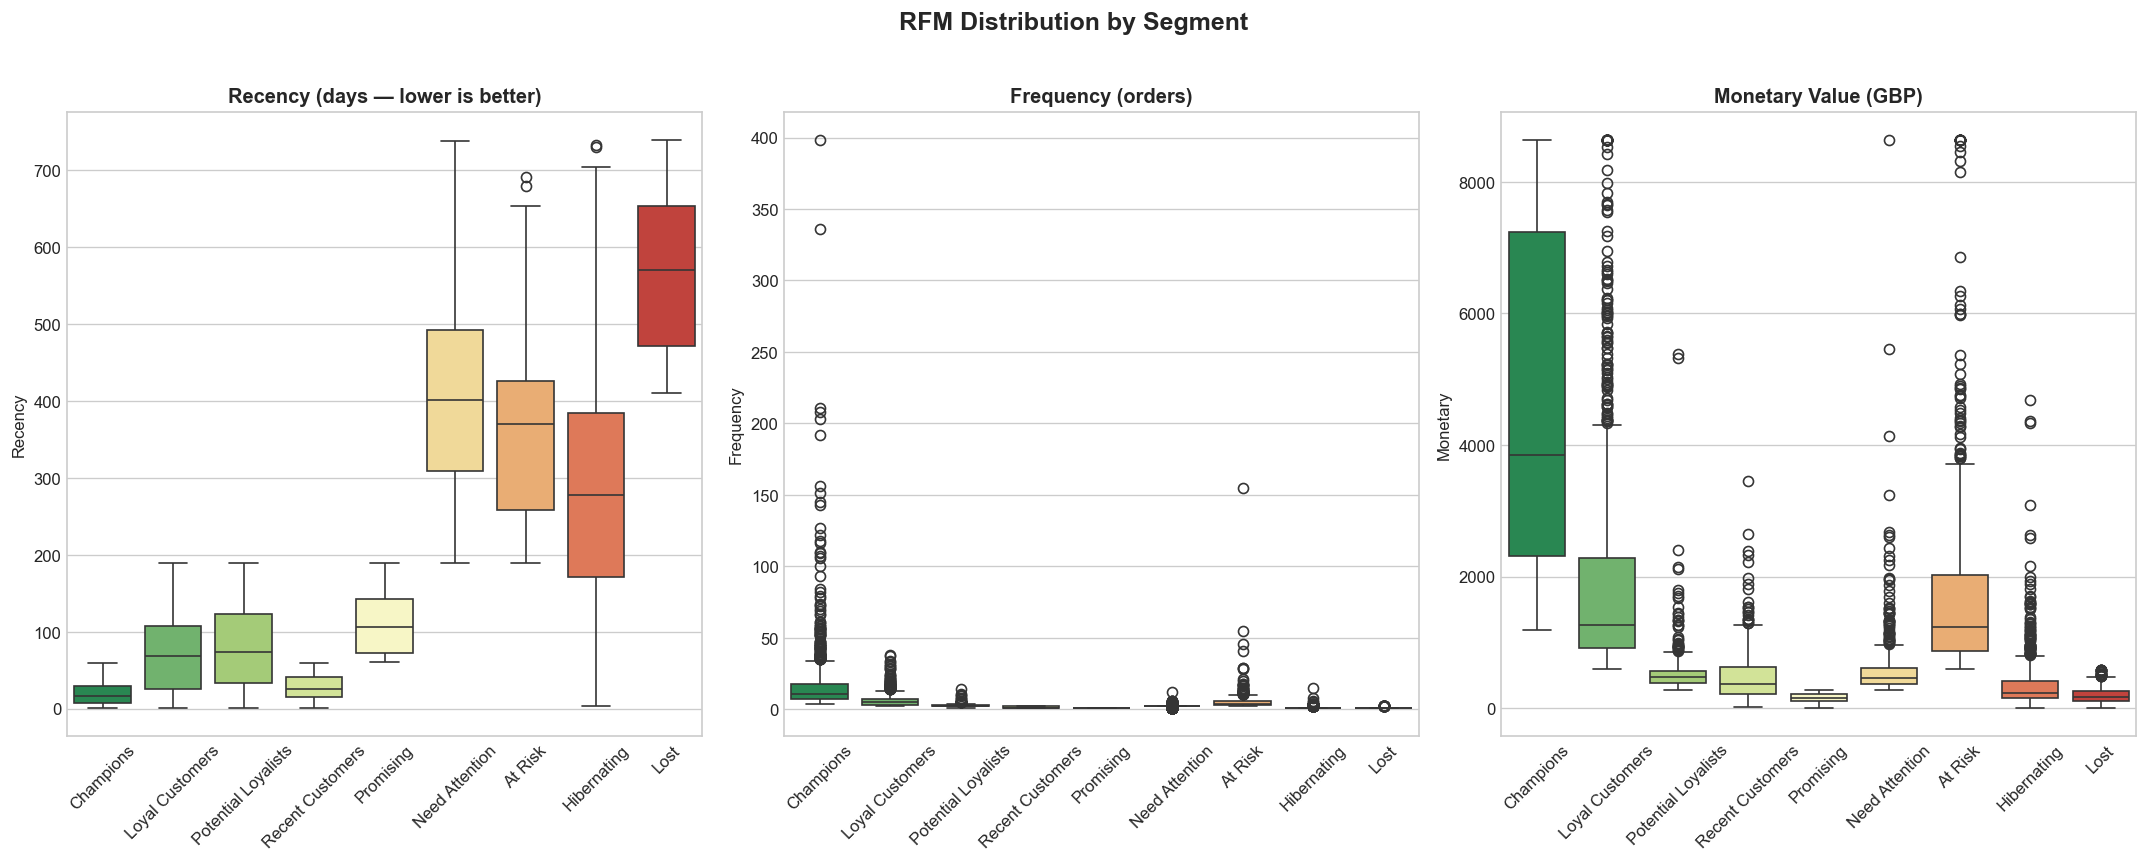

In [8]:
# ─── RFM Box Plots by Segment ──────────────────────────────
# Box plots show the distribution of R, F, M within each segment
# This validates our segmentation — Champions should have
# low recency, high frequency, high monetary
# If distributions overlap heavily, segments are not well-defined

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
metrics = ['Recency', 'Frequency', 'Monetary']
titles  = ['Recency (days — lower is better)', 
           'Frequency (orders)', 
           'Monetary Value (GBP)']

segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists',
                 'Recent Customers', 'Promising', 'Need Attention',
                 'At Risk', 'Cannot Lose Them', 'Hibernating', 'Lost']
segment_order = [s for s in segment_order if s in rfm['Segment'].unique()]

for ax, metric, title in zip(axes, metrics, titles):
    data = rfm.copy()
    if metric == 'Monetary':
        data[metric] = data[metric].clip(upper=data[metric].quantile(0.95))
    
    sns.boxplot(data=data, x='Segment', y=metric,
                order=segment_order, ax=ax, palette='RdYlGn_r')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('RFM Distribution by Segment', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/rfm_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# ─── Business Recommendations ──────────────────────────────
# This is where analytics becomes strategy
# For each segment: what is the business problem and what action solves it?
# This cell is what makes your project stand out from pure technical work

recommendations = {
    'Champions': {
        'size': len(rfm[rfm['Segment']=='Champions']),
        'revenue': rfm[rfm['Segment']=='Champions']['Monetary'].sum(),
        'problem': 'Risk of churn if ignored — they expect premium treatment',
        'action': 'Loyalty rewards, early access to new products, VIP program',
        'metric': 'Retention rate, NPS score'
    },
    'Loyal Customers': {
        'size': len(rfm[rfm['Segment']=='Loyal Customers']),
        'revenue': rfm[rfm['Segment']=='Loyal Customers']['Monetary'].sum(),
        'problem': 'Good customers who could become Champions with a push',
        'action': 'Upsell campaigns, membership tiers, personalised offers',
        'metric': 'Upgrade rate to Champions segment'
    },
    'At Risk': {
        'size': len(rfm[rfm['Segment']=='At Risk']),
        'revenue': rfm[rfm['Segment']=='At Risk']['Monetary'].sum(),
        'problem': 'Were good customers — now showing signs of disengagement',
        'action': 'Win-back campaigns, special discounts, feedback surveys',
        'metric': 'Reactivation rate within 90 days'
    },
    'Lost': {
        'size': len(rfm[rfm['Segment']=='Lost']),
        'revenue': rfm[rfm['Segment']=='Lost']['Monetary'].sum(),
        'problem': 'Disengaged — high cost to re-acquire',
        'action': 'Low-cost email re-engagement or sunset from active list',
        'metric': 'Cost per reactivation vs lifetime value'
    },
    'Cannot Lose Them': {
        'size': len(rfm[rfm['Segment']=='Cannot Lose Them']),
        'revenue': rfm[rfm['Segment']=='Cannot Lose Them']['Monetary'].sum(),
        'problem': 'High-value customers who have gone quiet recently',
        'action': 'Immediate personal outreach, premium win-back offer',
        'metric': 'Recovery rate within 30 days'
    }
}

print("=" * 70)
print("         BUSINESS RECOMMENDATIONS BY SEGMENT")
print("=" * 70)
for segment, info in recommendations.items():
    print(f"\n📌 {segment}")
    print(f"   Customers : {info['size']:,}")
    print(f"   Revenue   : £{info['revenue']:,.0f}")
    print(f"   Problem   : {info['problem']}")
    print(f"   Action    : {info['action']}")
    print(f"   Measure   : {info['metric']}")
    print("-" * 70)

         BUSINESS RECOMMENDATIONS BY SEGMENT

📌 Champions
   Customers : 1,299
   Revenue   : £10,622,565
   Problem   : Risk of churn if ignored — they expect premium treatment
   Action    : Loyalty rewards, early access to new products, VIP program
   Measure   : Retention rate, NPS score
----------------------------------------------------------------------

📌 Loyal Customers
   Customers : 1,139
   Revenue   : £2,369,746
   Problem   : Good customers who could become Champions with a push
   Action    : Upsell campaigns, membership tiers, personalised offers
   Measure   : Upgrade rate to Champions segment
----------------------------------------------------------------------

📌 At Risk
   Customers : 620
   Revenue   : £1,253,069
   Problem   : Were good customers — now showing signs of disengagement
   Action    : Win-back campaigns, special discounts, feedback surveys
   Measure   : Reactivation rate within 90 days
---------------------------------------------------------------

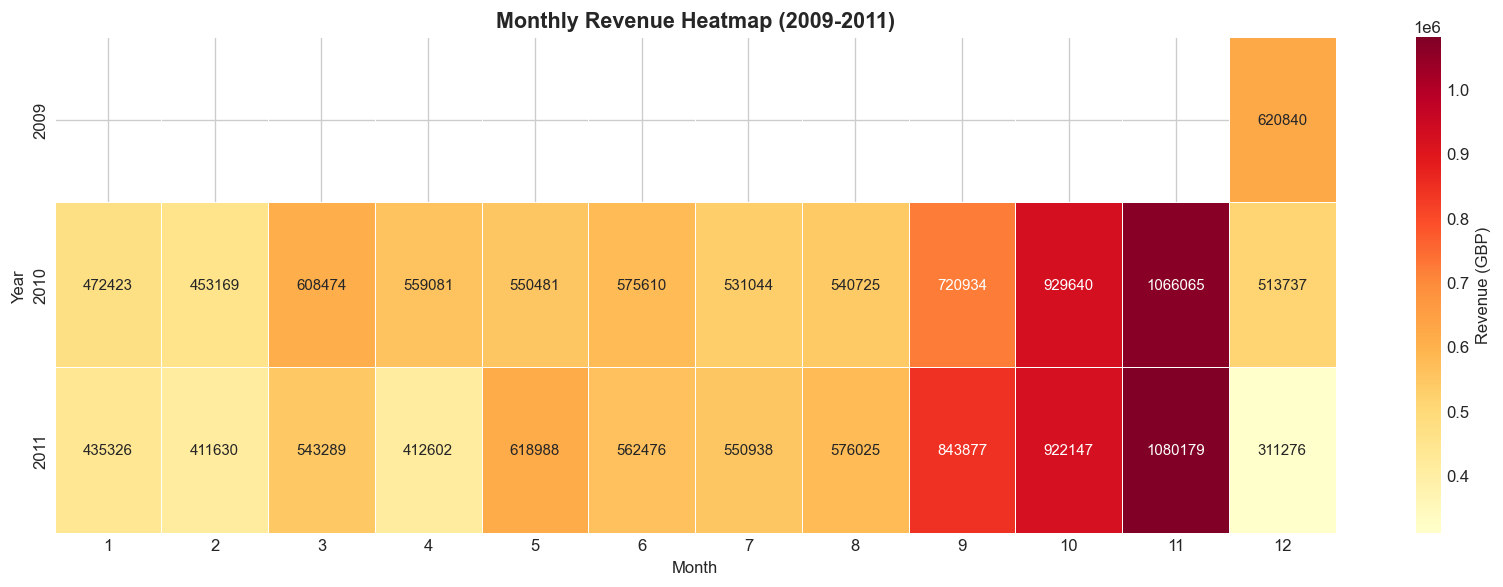

In [10]:
# ─── Cohort Revenue Heatmap ────────────────────────────────
# Shows revenue by month — reveals seasonality patterns
# Useful context for RFM: recency scores look different
# in Dec (peak) vs Feb (trough)

df['Year']  = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

cohort = df.groupby(['Year', 'Month'])['Revenue'].sum().unstack()

plt.figure(figsize=(14, 5))
sns.heatmap(cohort, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3,
            cbar_kws={'label': 'Revenue (GBP)'},
            annot_kws={'size': 9})
plt.title('Monthly Revenue Heatmap (2009-2011)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('../reports/cohort_revenue_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Key Insights & Storytelling

### 1. Revenue is highly concentrated
A small % of customers generate the majority of revenue (Pareto effect confirmed).
Champions and Loyal Customers together account for the bulk of total revenue
despite being a minority of the customer base.

### 2. Significant at-risk revenue
The "At Risk" and "Cannot Lose Them" segments represent customers who were 
previously high-value but are now disengaging. Immediate retention action 
could recover substantial revenue.

### 3. Large inactive base
The "Lost" and "Hibernating" segments represent a large pool of customers.
Re-engagement campaigns should be cost-evaluated — not all lost customers
are worth re-acquiring.

### 4. Seasonality impacts recency scores
Revenue peaks in Q4 (Oct-Dec) each year. Recency scores should be 
interpreted in the context of seasonal buying patterns.

### 5. ML clusters validate rule-based segments
K-Means clustering independently discovered groupings that largely align
with our rule-based segments — confirming the validity of both approaches.

Text(0.5, 1.0, 'RFM Correlation Matrix')

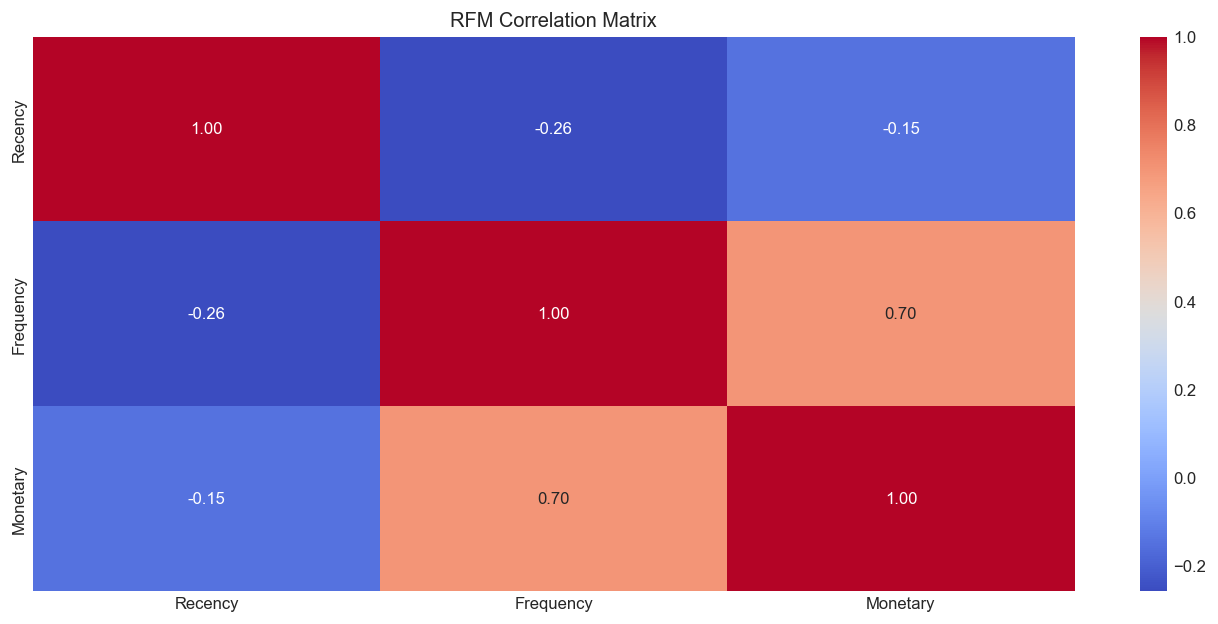

In [11]:
# Correlation between RFM metrics
corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('RFM Correlation Matrix')